### Required Discussion 16.1: Comparing Models

Now that you have seen a variety of models for regression and classification problems, it is good to step back and weigh the pros and cons of these options.  In the case of classification models, there are at least three things to consider:

1. Is the model good at handling imbalanced classes?
2. Does the model train quickly?
3. Does the model yield interpretable results?

Depending on your dataset and goals, the importance of these considerations will vary from project to project.  Your goal is to review our models to this point and discuss the pros and cons of each.  Two example datasets are offered as a way to offer two very different tasks where interpretability of the model may be of differing importance.

### Data and Task

Your goal is to discuss the pros and cons of Logistic Regression, Decision Trees, KNN, and SVM for the tasks below.  Consider at least the three questions above and list any additional considerations you believe are important to determining the "best" model for the task.  Share your response with your peers on the class discussion board.  

**TASK 1**: Predicting Customer Churn

Suppose you are tasked with producing a model to predict customer churn.  Which of your classification models would you use and what are the pros and cons of this model for this task?  Be sure to consider interpretability, imbalnced classes, and the speed of training.



In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.calibration import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn import pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

The data is loaded below.  Note that the handwritten digit data is already split into features and target (`digits`, `labels`). 

In [44]:
churn = pd.read_csv('data/telecom_churn.csv')

In [45]:
#churn data
churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [46]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [47]:
# Data Encoding

# Define features (X) and target (y)
X = churn.drop('Churn', axis=1)
y = churn['Churn']

le = LabelEncoder()
y = le.fit_transform(y)

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Models definition

models = {
    'logreg': (LogisticRegression(max_iter=1000), {'logreg__C': [0.1, 1, 10]}),
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'svc': (SVC(), {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf']}),
    'decisiontreeclassifier': (DecisionTreeClassifier(), {'decisiontreeclassifier__max_depth': [5, 10, 15]})
}


In [49]:
results = []
for name, (model, params) in models.items():

    pipe = Pipeline([("preprocessor", preprocessor), (name, model)])
    
    grid_search = GridSearchCV(pipe, param_grid=params, cv=5)
    grid_search.fit(X_train, y_train)
    
    time = grid_search.cv_results_['mean_fit_time'].sum()/len(grid_search.cv_results_['mean_fit_time'])
    train_score = grid_search.score(X_train, y_train)
    test_score = grid_search.score(X_test, y_test)

    results.append([name, train_score, test_score, time])

In [50]:

def results_to_df(results) -> pd.DataFrame:
    results_df = pd.DataFrame(results, columns=['model', 'train_score', 'test_score', 'fit_time'])
    results_df.set_index('model', inplace=True)
    return  results_df.sort_values(by='test_score', ascending=False)

results_to_df(results)

,train_score,test_score,fit_time
model,,,
decisiontreeclassifier,0.957614,0.937031,0.035328
svc,0.990248,0.926537,0.403327
knn,0.900600,0.877061,0.014043
logreg,0.870218,0.851574,0.034046


**TASK 2**: Recognizing Handwritten Digits

Suppose you are tasked with training a model to recognize handwritten digits.  Which of your classifier would you use here and why?  Again, be sure to consider the balance of classes, speed of training, and importance of interpretability.



In [51]:
from sklearn.datasets import load_digits

In [52]:
#X, y = load_digits(return_X_y=True)
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
results2 = []
for name, (model, params) in models.items():

    pipe = Pipeline([("scaler", StandardScaler()), (name, model)])

    grid_search = GridSearchCV(pipe, param_grid=params, cv=5)
    grid_search.fit(X_train, y_train)

    time = grid_search.cv_results_['mean_fit_time'].sum()/len(grid_search.cv_results_['mean_fit_time'])
    train_score = grid_search.score(X_train, y_train)
    test_score = grid_search.score(X_test, y_test)

    results2.append([name, train_score, test_score, time])

In [54]:
results_to_df(results2)

,train_score,test_score,fit_time
model,,,
svc,1.000000,0.980556,0.050347
logreg,0.998608,0.972222,0.033269
knn,0.988170,0.969444,0.002936
decisiontreeclassifier,1.000000,0.863889,0.012408


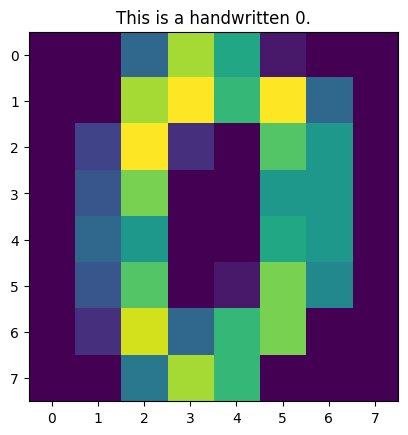

In [56]:
#example image
plt.imshow(digits.images[0].reshape(8, 8))
plt.title('This is a handwritten 0.');